In [2]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.7 MB/s eta 0:00:00


In [3]:

from ultralytics import YOLO

# Load a model
model = YOLO('yolov8n.yaml')  # build a new model from scratch
model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ZoDNF4xYazOUDXbmjyvF")
project = rf.workspace("jiyas-workspace-kk7db").project("hand_gesture_project-n0lln")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to hand_gesture_project-1 in yolov8:: 100%|██████████| 650/650 [00:00<00:00, 9294.68it/s]


In [5]:
import os

# check your dataset structure
!ls /content/hand_gesture_project-1/


data.yaml  README.roboflow.txt	test  train  valid


In [6]:
!cat /content/hand_gesture_project-1/data.yaml

names:
- fist
- peace
- stop
- thumbs up
nc: 4
roboflow:
  license: Private
  project: hand_gesture_project-n0lln
  url: https://app.roboflow.com/jiyas-workspace-kk7db/hand_gesture_project-n0lln/1
  version: 1
  workspace: jiyas-workspace-kk7db
test: ../test/images
train: ../train/images
val: ../valid/images


In [7]:
!nvidia-smi

Thu Jun 25 14:10:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
model.train(
    data='/content/hand_gesture_project-1/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='hand_gesture_model'
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hand_gesture_project-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hand_gesture_model, nbs=64, nms=False, opset=None, optimize=F

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a7b43f4a0f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

Check Results

In [9]:
# this shows your training curves
from ultralytics import YOLO

model = YOLO('/content/runs/detect/hand_gesture_model/weights/best.pt')

# check metrics
metrics = model.val()
print(f"mAP50: {metrics.box.map50:.4f}")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 782.8±258.2 MB/s, size: 22.5 KB)
val: Scanning /content/hand_gesture_project-1/valid/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 3.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.5it/s 0.2s
                   all         15         16      0.981        0.9      0.923      0.683
                  fist          4          4      0.986          1      0.995      0.752
                 peace          3          3      0.971          1      0.995      0.863
                  stop          4          4      0.982          1      0.995      0.739
             thumbs up          4          5      0.987        0.6      0.706      0.377
Speed: 1.6ms preprocess, 6.5ms inference,

Run inference on a test image

In [11]:
results = model('/content/hand_gesture_project-1/test/images')

# save results
for r in results:
    r.save(filename=f'result_{results.index(r)}.jpg')


image 1/9 /content/hand_gesture_project-1/test/images/A-6-_jpg.rf.a30c8541609285e7dbef465cfb861d70.jpg: 640x640 1 fist, 8.0ms
image 2/9 /content/hand_gesture_project-1/test/images/IMG_6418_JPG.rf.e9a3d040ec5e8394106a960a010c5c17.jpg: 640x640 1 peace, 7.2ms
image 3/9 /content/hand_gesture_project-1/test/images/IMG_6422_JPG.rf.102dbf3fce2ec5a007230fde4d91e8ba.jpg: 640x640 1 peace, 7.1ms
image 4/9 /content/hand_gesture_project-1/test/images/Thumbs-14_png.rf.b9bf0de5b7fe5b8235b08d99416365b6.jpg: 640x640 1 thumbs up, 7.7ms
image 5/9 /content/hand_gesture_project-1/test/images/Thumbs-3_png.rf.873358caa5620ff84810c122f0e43230.jpg: 640x640 1 thumbs up, 7.2ms
image 6/9 /content/hand_gesture_project-1/test/images/Thumbs-7_jpeg.rf.44f2ac17f2a28f8672ff3e04879006be.jpg: 640x640 2 thumbs ups, 7.2ms
image 7/9 /content/hand_gesture_project-1/test/images/Thumbs-9_jpeg.rf.5d5036eb2d3292a7aac6dd9ab946d061.jpg: 640x640 1 thumbs up, 7.2ms
image 8/9 /content/hand_gesture_project-1/test/images/WIN_20240104_

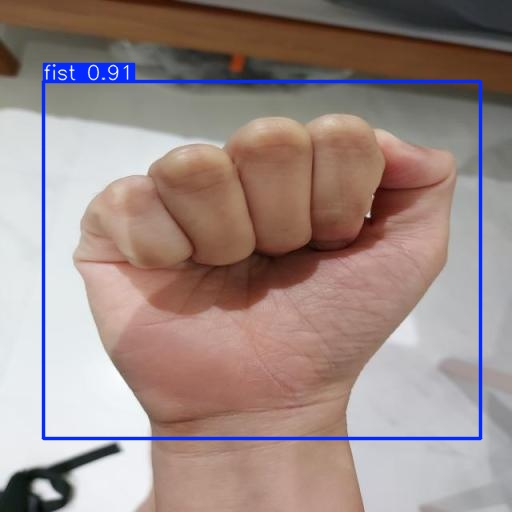

In [20]:
from IPython.display import Image
import os

# show first result
Image('/content/result_0.jpg')

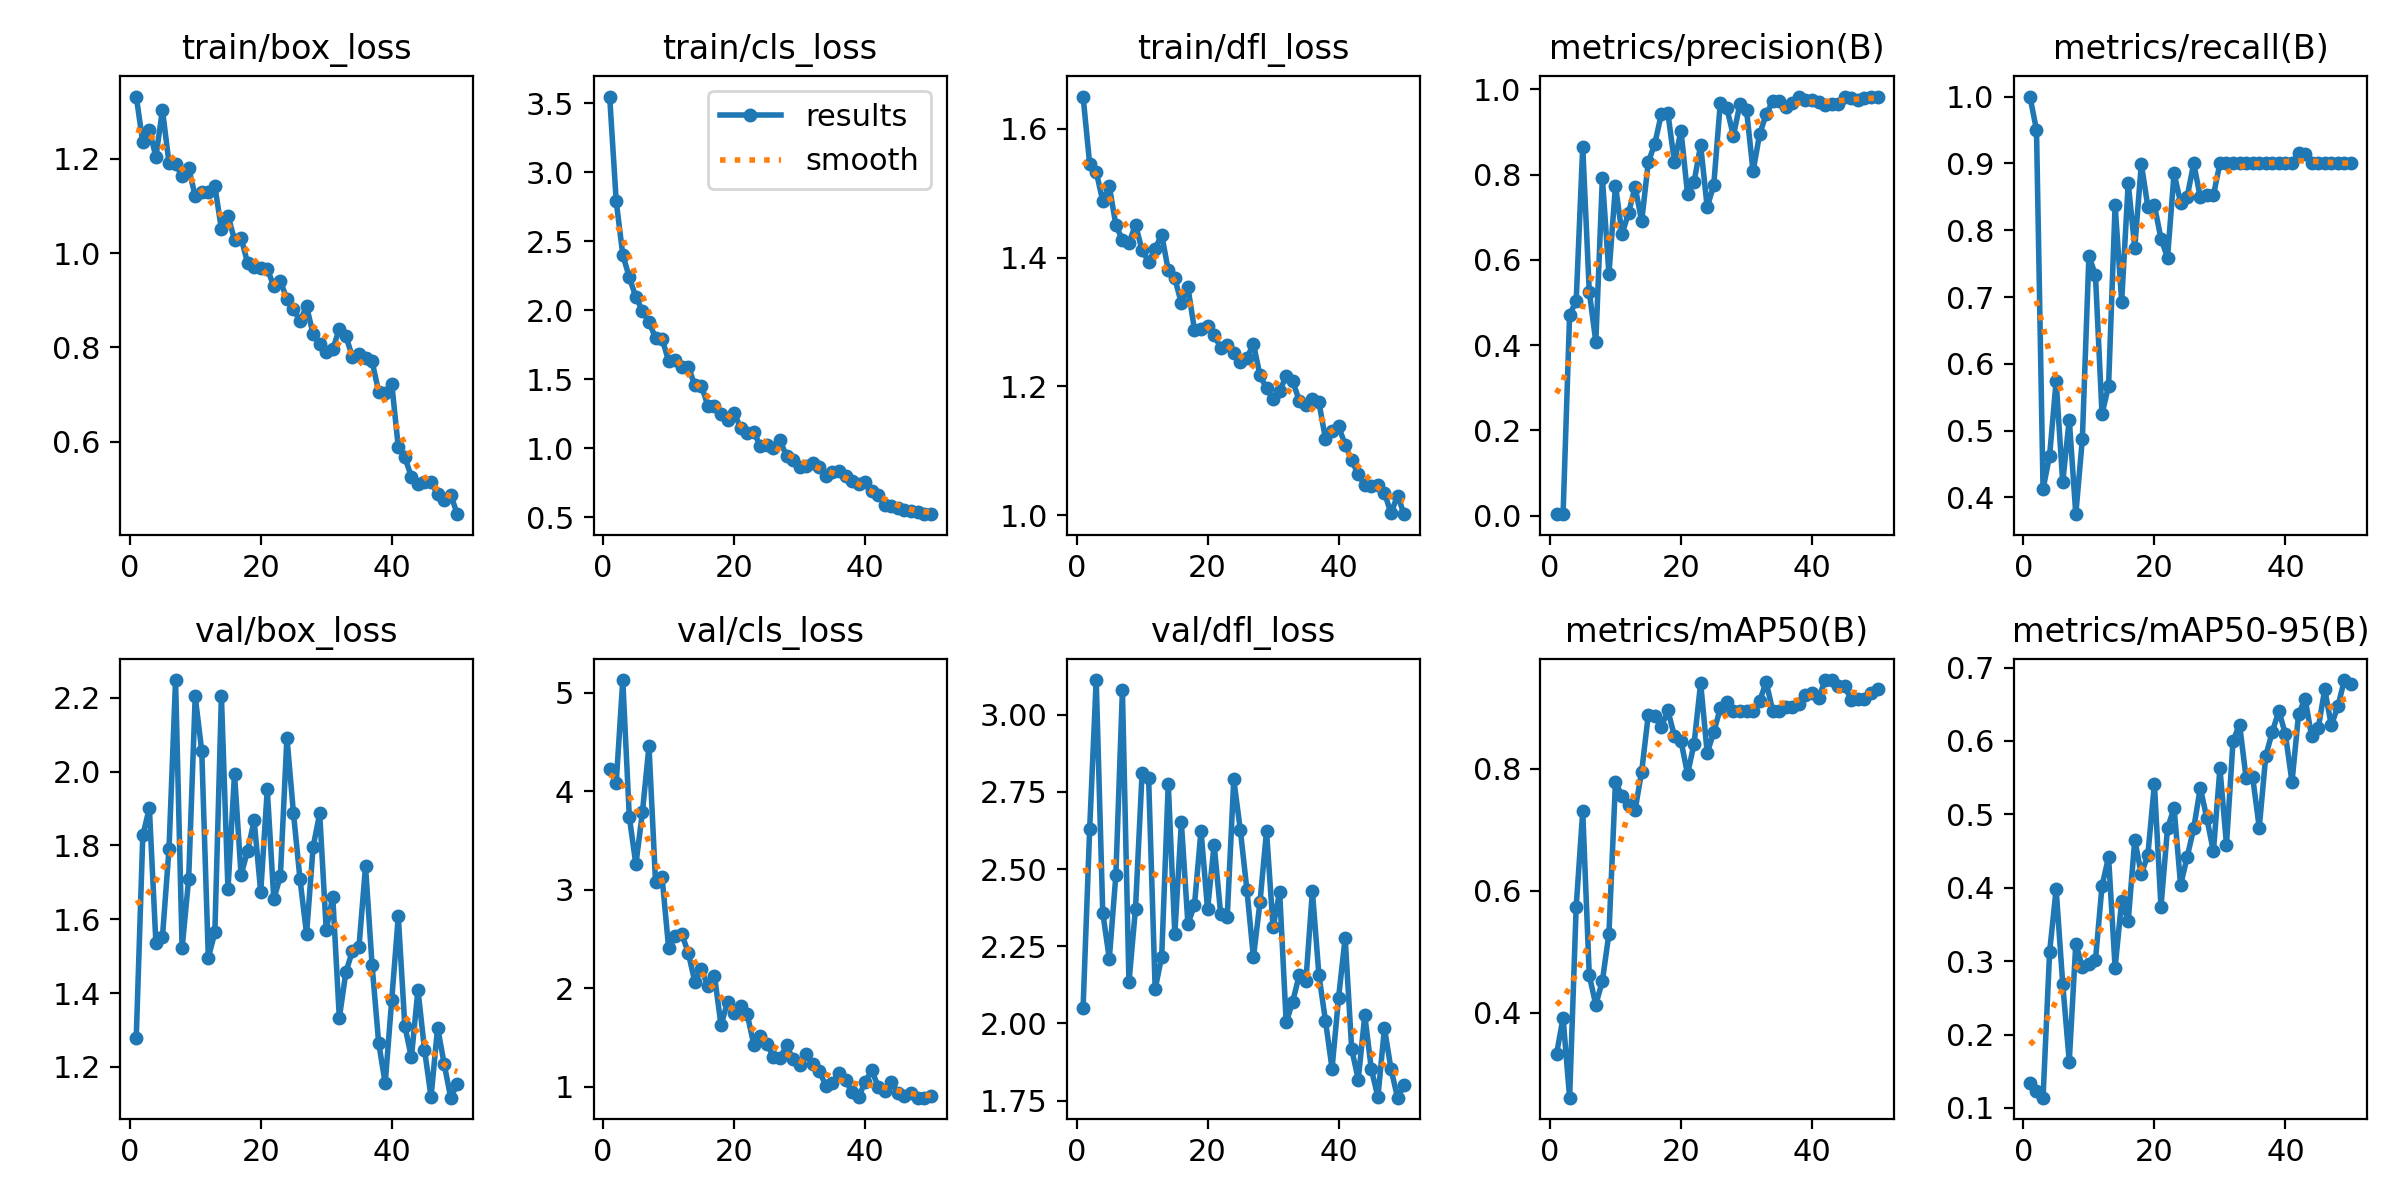

In [21]:
Image('/content/runs/detect/hand_gesture_model/results.png')

In [22]:
from google.colab import files
files.download('/content/runs/detect/hand_gesture_model/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# download training curves
files.download('/content/runs/detect/hand_gesture_model/results.png')

# download confusion matrix
files.download('/content/runs/detect/hand_gesture_model/confusion_matrix.png')\

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>